2. Predicting Stock Prices: Develop a time series prediction model to
forecast stock prices.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense


In [10]:
# Load dataset
df = pd.read_csv("/content/drive/MyDrive/AIML_LAB/ep2,3,4_Reguesion/stock_price_timeseries_dataset.csv")



         Date Stock    Open    High     Low   Close   Volume
0  2020-01-01  AAPL  173.80  174.75  173.68  174.43  8204212
1  2020-01-02  AAPL  176.01  177.59  174.07  177.55  2766891
2  2020-01-03  AAPL  177.57  178.37  176.62  176.71  5721339
3  2020-01-06  AAPL  176.01  177.58  171.33  171.73  9242680
4  2020-01-07  AAPL  171.85  172.20  170.69  170.82  4416664


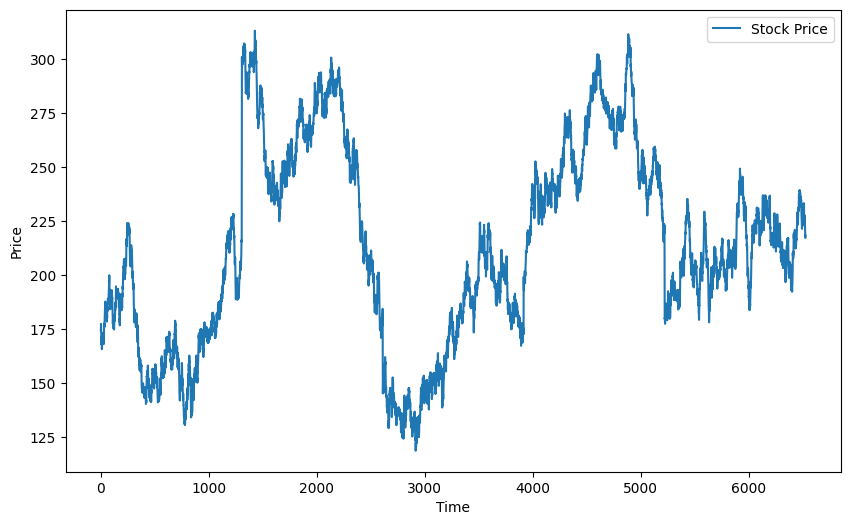

In [11]:
# Check first few rows
print(df.head())

# Plot stock prices
plt.figure(figsize=(10,6))
plt.plot(df['Close'], label='Stock Price')
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

In [12]:

data = df['Close'].values.reshape(-1,1)

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

In [13]:
def create_sequences(dataset, time_step=60):
    X, y = [], []
    for i in range(len(dataset)-time_step-1):
        X.append(dataset[i:(i+time_step), 0])
        y.append(dataset[i+time_step, 0])
    return np.array(X), np.array(y)

time_step = 60
X, y = create_sequences(scaled_data, time_step)

# Reshape for LSTM [samples, time steps, features]
X = X.reshape(X.shape[0], X.shape[1], 1)

In [14]:
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(time_step, 1)))
model.add(LSTM(50, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [16]:
model.fit(X, y, batch_size=64, epochs=20, verbose=1)

Epoch 1/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 2.9584e-04
Epoch 2/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step - loss: 2.8753e-04
Epoch 3/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - loss: 2.7807e-04
Epoch 4/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - loss: 2.1743e-04
Epoch 5/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - loss: 2.4822e-04
Epoch 6/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - loss: 2.5735e-04
Epoch 7/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step - loss: 2.1915e-04
Epoch 8/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 2.9373e-04
Epoch 9/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - loss: 2.1537e-04
Epoch 10/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - loss: 2.3021e-04
Epoch 11/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - loss: 1.8466e-04
Epoch 12/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - loss: 2.2854e-04
Epoch 13/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 11s 67ms/step - loss: 1.9181e-04
Epoch 14/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - lo

202/202 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step


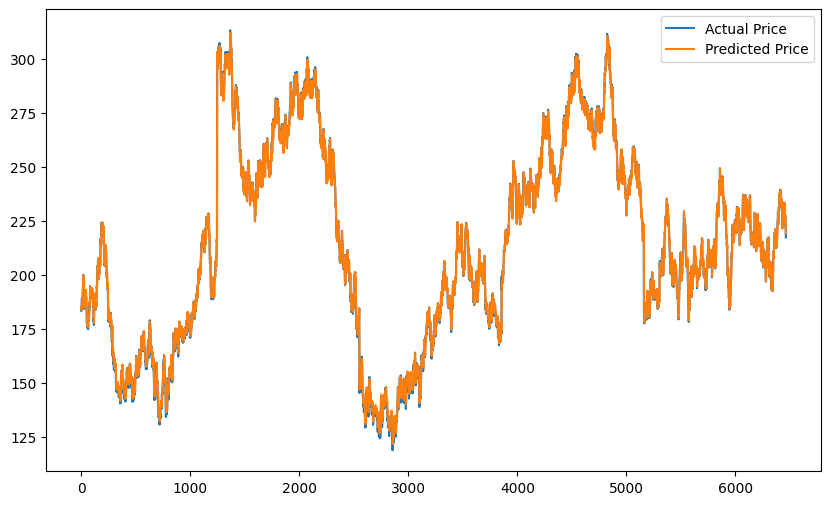

In [17]:
train_predict = model.predict(X)

# Inverse transform to original scale
train_predict = scaler.inverse_transform(train_predict)
y_true = scaler.inverse_transform(y.reshape(-1,1))

# Plot predictions vs actual
plt.figure(figsize=(10,6))
plt.plot(y_true, label="Actual Price")
plt.plot(train_predict, label="Predicted Price")
plt.legend()
plt.show()

In [ ]:
last_60_days = scaled_data[-60:]
X_future = last_60_days.reshape(1, time_step, 1)

future_price = model.predict(X_future)
future_price = scaler.inverse_transform(future_price)

print("Predicted next day price:", future_price[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 545ms/step
Predicted next day price: 217.88962
